# P7 — Thematic Alignment in Scientific Journals
## *Ecological Economics* (ISSN 0921-8009)

**Course:** Natural Language Processing  
**Student:** Sofya Strelskaya  
**Institution:** Università degli Studi di Milano  

---

### Research Question

> *Do the articles published in Ecological Economics actually align with the journal's stated Aims & Scope — and has this alignment changed over time?*

### Pipeline Overview

| Step | What we do | Tools |
|------|-----------|-------|
| 1 | Load and inspect the corpus | `pandas`, `json` |
| 2 | Define the thematic reference | Aims & Scope text |
| 3 | Embed text into vector space | `sentence-transformers` |
| 4 | Compute alignment scores | cosine similarity |
| 5 | Detect thematic drift over time | year-level aggregation |
| 6 | Identify outlier papers | score distribution |
| 7 | Topic modelling | `BERTopic` |
| 8 | Qualitative validation | manual inspection |

---
## 0. Imports and Setup

In [1]:
# Standard library
import json
import warnings
from pathlib import Path
from collections import Counter

# Data
import numpy as np
import pandas as pd

# NLP
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from bertopic import BERTopic

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings("ignore")

# Consistent plot style
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120

print("All imports OK.")

/Users/sofyastrelskaya/Desktop/ecological-economics-alignment/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


All imports OK.


---
## 1. Load the Corpus

We collected abstracts from *Ecological Economics* (2014–2024) using the Elsevier ScienceDirect and Scopus APIs. Each paper is stored as one JSON object per line in a `.jsonl` file.

In [2]:
PAPERS_PATH = Path("../data/raw/papers.jsonl")

def load_jsonl(path: Path) -> list[dict]:
    with path.open(encoding="utf-8") as f:
        return [json.loads(line) for line in f if line.strip()]

papers = load_jsonl(PAPERS_PATH)
print(f"Loaded {len(papers)} papers.")
print(f"\nExample entry:")
print(json.dumps(papers[0], indent=2, ensure_ascii=False)[:600] + "...")

Loaded 2121 papers.

Example entry:
{
  "title": "Present bias predicts participation in payments for environmental services: Evidence from a behavioral experiment in Uganda",
  "doi": "10.1016/j.ecolecon.2014.07.026",
  "date": "2014-12-01",
  "year": 2014,
  "abstract": "Farmers are necessary agents in global efforts to conserve the environment now that croplands and pastures together constitute the largest terrestrial system on Earth - covering some 48% of ice-free land surface. Whereas standard economic models predict that farmers will participate in conservation programs so long as they are profitable, empirical findings fr...


In [3]:
# building a dataframe
df = pd.DataFrame(papers)
df["year"] = df["year"].astype(int)
df["abstract_len"] = df["abstract"].str.len()

print(f"Shape: {df.shape}")
df.head(3)

Shape: (2121, 6)


,title,doi,date,year,abstract,abstract_len
0,Present bias predicts participation in payment...,10.1016/j.ecolecon.2014.07.026,2014-12-01,2014,Farmers are necessary agents in global efforts...,1351
1,Socio-cultural valuation of ecosystem services...,10.1016/j.ecolecon.2014.09.028,2014-12-01,2014,Ecosystem services studies currently lack info...,1525
2,"Environmental protection goals, policy & publi...",10.1016/j.ecolecon.2014.09.025,2014-12-01,2014,One of the most divisive debates in modern agr...,1296


### 1.1 Corpus Overview

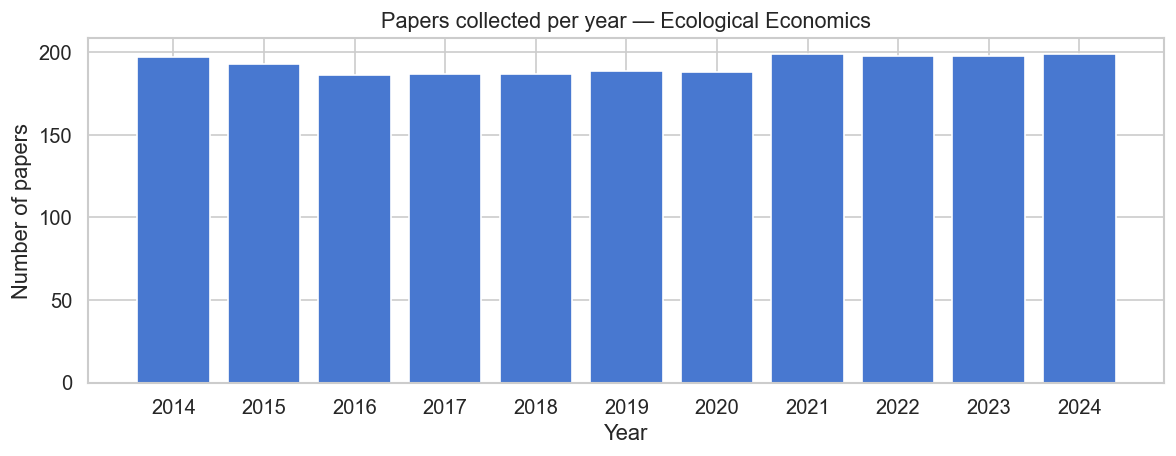

 year  count
 2014    197
 2015    193
 2016    186
 2017    187
 2018    187
 2019    189
 2020    188
 2021    199
 2022    198
 2023    198
 2024    199

Total: 2121 papers
Median abstract length: 1292 characters


In [4]:
# Papers per year
papers_per_year = df.groupby("year").size().reset_index(name="count")

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(papers_per_year["year"], papers_per_year["count"],
       color=sns.color_palette("muted")[0], edgecolor="white")
ax.set_title("Papers collected per year — Ecological Economics", fontsize=13)
ax.set_xlabel("Year")
ax.set_ylabel("Number of papers")
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.tight_layout()
plt.savefig("../data/fig_corpus_overview.png", dpi=150)
plt.show()

print(papers_per_year.to_string(index=False))
print(f"\nTotal: {len(df)} papers")
print(f"Median abstract length: {df['abstract_len'].median():.0f} characters")

---
## 2. Thematic Reference — Aims & Scope

The journal's Aims & Scope statement serves as our **ground truth** — the official description of what the journal is supposed to publish. We embed this text into the same vector space as the abstracts, so we can measure distance between them.

We use only the thematic paragraphs (not the submission guidelines section), to keep the reference vector focused on content rather than process.

In [5]:
SCOPE_PATH = Path("../data/aims_scope.txt")

with SCOPE_PATH.open(encoding="utf-8") as f:
    scope_text = f.read().strip()

print(f"Aims & Scope text ({len(scope_text)} characters):\n")
print(scope_text)

Aims & Scope text (1865 characters):

The Transdisciplinary Journal of the International Society for Ecological Economics (ISEE)

The journal is concerned with extending and integrating the understanding of the interfaces and interplay between "nature's household" (ecosystems) and "humanity's household" (the economy). Ecological economics is an interdisciplinary field defined by a set of concrete problems or challenges related to governing economic activity in a way that promotes human well-being, sustainability, and justice. The journal thus emphasizes critical work that draws on and integrates elements of ecological science, economics, and the analysis of values, behaviors, cultural practices, institutional structures, and societal dynamics. The journal is transdisciplinary in spirit and methodologically open, drawing on the insights offered by a variety of intellectual traditions, and appealing to a diverse readership.

Specific research areas covered include: valuation of natural r

---
## 3. Text Embeddings with Sentence-BERT

We use **Sentence-BERT** (`all-MiniLM-L6-v2`) to convert each abstract and the Aims & Scope text into a dense vector of 384 dimensions. Each vector captures the semantic meaning of the text in a way that allows mathematical comparison.

**Why Sentence-BERT?**  
Unlike word embeddings (Word2Vec, GloVe) that represent individual words, Sentence-BERT produces a single vector for an entire sentence or paragraph, preserving context and meaning across the full text. This makes it ideal for comparing documents thematically rather than lexically.

**Why `all-MiniLM-L6-v2`?**  
It is fast, memory-efficient, and performs well on semantic similarity tasks — a good balance between quality and computational cost for a corpus of ~2000 abstracts on a laptop.

In [6]:
# Load model (downloads ~80MB on first run, then cached locally)
print("Loading Sentence-BERT model...")
model = SentenceTransformer("all-MiniLM-L6-v2")
print("Model loaded.")

# Embed the Aims & Scope — this is our reference vector
print("\nEmbedding Aims & Scope...")
scope_vec = model.encode(scope_text, normalize_embeddings=True)
print(f"Scope vector shape: {scope_vec.shape}")

Loading Sentence-BERT model...


Loading weights: 100%|█| 103


Model loaded.

Embedding Aims & Scope...
Scope vector shape: (384,)


In [7]:
# Embed all abstracts (takes ~1-2 minutes for 2000 papers)
abstracts = df["abstract"].tolist()

print(f"Embedding {len(abstracts)} abstracts...")
abstract_vecs = model.encode(
    abstracts,
    normalize_embeddings=True,
    show_progress_bar=True,
    batch_size=64,
)
print(f"\nAbstract matrix shape: {abstract_vecs.shape}")
print("Done.")

# Save embeddings to disk so we don't have to recompute them
np.save("../data/abstract_vecs.npy", abstract_vecs)
np.save("../data/scope_vec.npy", scope_vec)
print("Embeddings saved to data/")

Embedding 2121 abstracts...


Batches: 100%|█| 34/34 [00:1


Abstract matrix shape: (2121, 384)
Done.
Embeddings saved to data/


---
## 4. Alignment Scores

We compute **cosine similarity** between each abstract vector and the Aims & Scope vector. This gives us a score between 0 and 1 for each paper:

- **Score close to 1** → the paper's content is very close to the journal's stated focus
- **Score close to 0** → the paper reads as thematically distant from the stated scope

$$\text{alignment}(p) = \cos(\vec{p},\ \vec{\text{scope}}) = \frac{\vec{p} \cdot \vec{\text{scope}}}{\|\vec{p}\|\ \|\vec{\text{scope}}\|}$$

Because we used `normalize_embeddings=True`, both vectors already have unit length, so the dot product directly equals the cosine similarity.

In [14]:
# Load embeddings if restarting the notebook
# abstract_vecs = np.load("../data/abstract_vecs.npy")
# scope_vec     = np.load("../data/scope_vec.npy")

# Compute cosine similarity for every paper
scores = cosine_similarity(abstract_vecs, scope_vec.reshape(1, -1)).flatten()
df["alignment_score"] = scores

print("Alignment score summary:")
print(df["alignment_score"].describe().round(4))

Alignment score summary:
count    2121.0000
mean        0.3498
std         0.1018
min         0.0057
25%         0.2808
50%         0.3467
75%         0.4132
max         0.7213
Name: alignment_score, dtype: float64


In [15]:
# Sanity check — manually verify 3 specific papers
check_indices = [
    df["alignment_score"].idxmax(),   # highest scoring paper
    df["alignment_score"].idxmin(),   # lowest scoring paper
    df.index[len(df)//2],             # a random middle paper
]

for idx in check_indices:
    row = df.iloc[idx]
    print(f"{'='*65}")
    print(f"Score : {row['alignment_score']:.4f}")
    print(f"Title : {row['title']}")
    print(f"Abstract (first 200 chars):")
    print(f"{row['abstract'][:200]}")
    print()

Score : 0.7213
Title : Why ecological economics needs to return to its roots: The biophysical foundation of socio-economic systems
Abstract (first 200 chars):
Ecological economics was formally established in 1989 with the ambitious vision of developing a new economic paradigm embedding the social and economic systems in the biophysical world. Ecological eco

Score : 0.0057
Title : Corrigendum to Moral Foundations and Voluntary Public Good Provision: The Case of Climate Change (Ecological Economics (2020) 175, (S0921800919315319), (10.1016/j.ecolecon.2020.106696))
Abstract (first 200 chars):
The authors regret two reporting errors (wrong signs) in Table A2. The correct coefficient of the regression of Care with respect to Left-Right Scale is −0.02: The correct coefficient of the regressio

Score : 0.6020
Title : On the Circular Bioeconomy and Decoupling: Implications for Sustainable Growth
Abstract (first 200 chars):
This paper explores the existing confusion around the conceptual defin

In [16]:
# Second lowest scoring paper
second_min = df.nsmallest(2, "alignment_score").iloc[1]
print(f"Score : {second_min['alignment_score']:.4f}")
print(f"Title : {second_min['title']}")
print(f"Year  : {second_min['year']}")
print(f"\nAbstract:\n{second_min['abstract']}")

Score : 0.0288
Title : The Role of Agricultural Training on Fertilizer Use Knowledge: A Randomized Controlled Experiment
Year  : 2018

Abstract:
Improving farmers’ knowledge of fertilizer use through agricultural training has been considered a prerequisite to scientific fertilizer management. However, empirical evidence of the effect of agricultural training on farmers’ fertilizer management knowledge is inconclusive. Based on a randomized controlled experiment involving 687 farmers that mitigates selection bias in the data, this paper identifies the treatment effect of agricultural training on farmers’ fertilizer management knowledge in Chinese rice production. Results indicate that the fertilizer management knowledge of field-guidance farmers improved by almost 40%. However, such knowledge acquisition did not occur for curriculum-trained farmers. We also find that there is no evidence of knowledge diffusion from trained farmers to exposed farmers in the same village.


### 4.1 Score Distribution

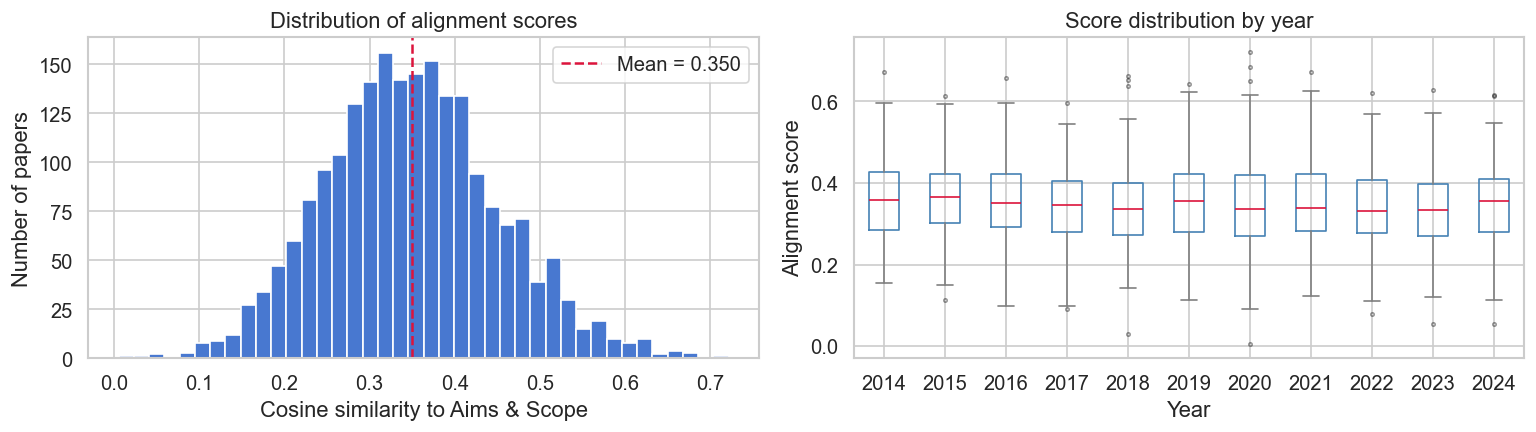

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histogram
axes[0].hist(df["alignment_score"], bins=40,
             color=sns.color_palette("muted")[0], edgecolor="white")
axes[0].axvline(df["alignment_score"].mean(), color="crimson",
                linestyle="--", label=f'Mean = {df["alignment_score"].mean():.3f}')
axes[0].set_title("Distribution of alignment scores")
axes[0].set_xlabel("Cosine similarity to Aims & Scope")
axes[0].set_ylabel("Number of papers")
axes[0].legend()

# Box plot by year
df.boxplot(column="alignment_score", by="year", ax=axes[1],
           color=dict(boxes="steelblue", whiskers="gray",
                      medians="crimson", caps="gray"),
           flierprops=dict(marker="o", markersize=2, alpha=0.4))
axes[1].set_title("Score distribution by year")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Alignment score")
plt.suptitle("")

plt.tight_layout()
plt.savefig("../data/fig_score_distribution.png", dpi=150)
plt.show()

---
## 5. Thematic Drift Over Time

We aggregate alignment scores by year to detect whether the journal has drifted closer to or further from its stated scope over the study period.

In [18]:
yearly = (
    df.groupby("year")["alignment_score"]
    .agg(mean="mean", std="std", median="median", count="count")
    .reset_index()
)

# 95% confidence interval on the mean
yearly["ci95"] = 1.96 * yearly["std"] / np.sqrt(yearly["count"])

print(yearly.round(4).to_string(index=False))

 year   mean    std  median  count   ci95
 2014 0.3615 0.1040  0.3579    197 0.0145
 2015 0.3691 0.1019  0.3649    193 0.0144
 2016 0.3537 0.0971  0.3515    186 0.0140
 2017 0.3436 0.0922  0.3472    187 0.0132
 2018 0.3397 0.0966  0.3361    187 0.0138
 2019 0.3595 0.1033  0.3560    189 0.0147
 2020 0.3501 0.1186  0.3366    188 0.0170
 2021 0.3515 0.1065  0.3378    199 0.0148
 2022 0.3365 0.1001  0.3313    198 0.0139
 2023 0.3347 0.0963  0.3347    198 0.0134
 2024 0.3479 0.0980  0.3553    199 0.0136


In [19]:
# Flag non-research content
editorial_keywords = ["corrigendum", "erratum", "book review", "correction to"]

df["is_editorial"] = df["title"].str.lower().str.contains(
    "|".join(editorial_keywords), na=False
)

print(f"Editorial/correction notices : {df['is_editorial'].sum()}")
print(f"Research papers              : {(~df['is_editorial']).sum()}")

# Create a clean research-only dataframe for analysis
df_research = df[~df["is_editorial"]].copy()
print(f"\nMean score — all papers      : {df['alignment_score'].mean():.4f}")
print(f"Mean score — research only   : {df_research['alignment_score'].mean():.4f}")

Editorial/correction notices : 16
Research papers              : 2105

Mean score — all papers      : 0.3498
Mean score — research only   : 0.3508


In [20]:
# Compare early period vs late period
df_research["period"] = df_research["year"].apply(
    lambda y: "2014–2018" if y <= 2018 else "2019–2024"
)

period_stats = df_research.groupby("period")["alignment_score"].agg(
    mean="mean", std="std", count="count"
).round(4)

print(period_stats)

             mean     std  count
period                          
2014–2018  0.3542  0.0986    945
2019–2024  0.3480  0.1031   1160


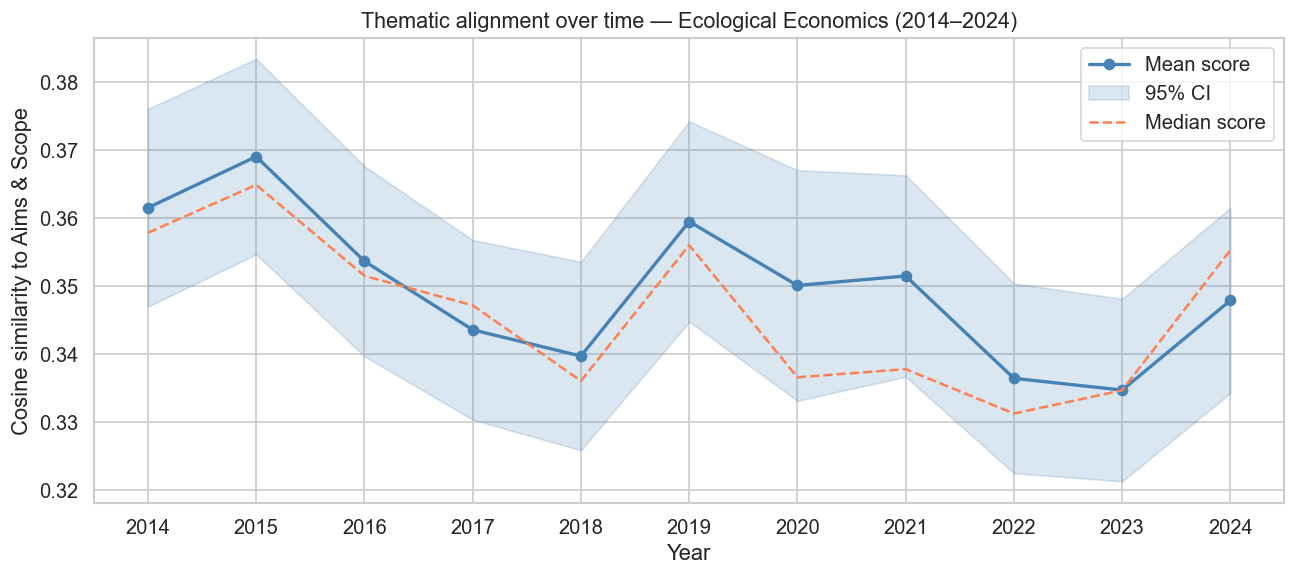

In [21]:
fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(yearly["year"], yearly["mean"],
        marker="o", color="steelblue", linewidth=2, label="Mean score")
ax.fill_between(
    yearly["year"],
    yearly["mean"] - yearly["ci95"],
    yearly["mean"] + yearly["ci95"],
    alpha=0.2, color="steelblue", label="95% CI"
)
ax.plot(yearly["year"], yearly["median"],
        linestyle="--", color="coral", linewidth=1.5, label="Median score")

ax.set_title("Thematic alignment over time — Ecological Economics (2014–2024)",
             fontsize=13)
ax.set_xlabel("Year")
ax.set_ylabel("Cosine similarity to Aims & Scope")
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
ax.legend()
plt.tight_layout()
plt.savefig("../data/fig_drift.png", dpi=150)
plt.show()

---
## 6. Outlier Detection

We define outliers as papers whose alignment score falls **more than 1.5 standard deviations below the mean** — i.e., papers that are unusually far from the journal's stated scope. We also inspect the top-scoring papers for contrast.

In [22]:
mean_score = df["alignment_score"].mean()
std_score  = df["alignment_score"].std()
threshold  = mean_score - 1.5 * std_score

outliers   = df[df["alignment_score"] < threshold].sort_values("alignment_score")
top_papers = df.nlargest(10, "alignment_score")

print(f"Mean score  : {mean_score:.4f}")
print(f"Std dev     : {std_score:.4f}")
print(f"Threshold   : {threshold:.4f}")
print(f"Outliers    : {len(outliers)} papers ({100*len(outliers)/len(df):.1f}% of corpus)")

Mean score  : 0.3498
Std dev     : 0.1018
Threshold   : 0.1970
Outliers    : 130 papers (6.1% of corpus)


### 6.1 Most aligned papers (top 10)

In [23]:
cols = ["year", "alignment_score", "title", "doi"]
pd.set_option("display.max_colwidth", 80)
top_papers[cols].reset_index(drop=True)

,year,alignment_score,title,doi
0,2020,0.721281,Why ecological economics needs to return to its roots: The biophysical found...,10.1016/j.ecolecon.2019.106567
1,2020,0.684162,Between Ostrom and Nordhaus: The research landscape of sustainability economics,10.1016/j.ecolecon.2020.106620
2,2021,0.672815,"Integrating the green economy, circular economy and bioeconomy in a strategi...",10.1016/j.ecolecon.2021.107143
3,2014,0.671550,The second generation of ecological economics: How far has the apple fallen ...,10.1016/j.ecolecon.2014.09.020
4,2018,0.661205,Searching for a Scientific Paradigm in Ecological Economics: The History of ...,10.1016/j.ecolecon.2018.07.022
5,2016,0.657068,Influential publications in ecological economics revisited,10.1016/j.ecolecon.2016.01.007
6,2018,0.651745,Mainstream economics toolkit within the ecological economics framework,10.1016/j.ecolecon.2017.10.024
7,2020,0.649940,The Ecological Economics of Economic Democracy,10.1016/j.ecolecon.2020.106750
8,2019,0.642986,Avoiding dualisms in ecological economics: Towards a dialectically-informed ...,10.1016/j.ecolecon.2019.05.004
9,2018,0.637676,Re-establishing Justice as a Pillar of Ecological Economics Through Feminist...,10.1016/j.ecolecon.2018.05.022


### 6.2 Least aligned papers — outliers

In [24]:
outliers[cols].reset_index(drop=True)

,year,alignment_score,title,doi
0,2020,0.005689,Corrigendum to Moral Foundations and Voluntary Public Good Provision: The Ca...,10.1016/j.ecolecon.2020.106786
1,2018,0.028818,The Role of Agricultural Training on Fertilizer Use Knowledge: A Randomized ...,10.1016/j.ecolecon.2018.02.004
2,2023,0.053233,Can market segmentation improve the performance of water quality trading auc...,10.1016/j.ecolecon.2023.107934
3,2024,0.053520,Fighting crime to improve recycling: Evaluating an anti-mafia policy on sour...,10.1016/j.ecolecon.2024.108291
4,2022,0.078062,Particulate matter and COVID-19 excess deaths: Decomposing long-term exposur...,10.1016/j.ecolecon.2022.107340
...,...,...,...,...
125,2016,0.193726,Can urban areas help sustain the preservation of open space? Evidence from s...,10.1016/j.ecolecon.2016.06.026
126,2021,0.194689,Impact of aircraft lifetime change on lifecycle CO2 emissions and costs in J...,10.1016/j.ecolecon.2021.107104
127,2021,0.194714,Smallholder farmer preferences for diversifying farming with cover crops of ...,10.1016/j.ecolecon.2021.107060
128,2018,0.194805,Do Mature Economies Grow Exponentially?,10.1016/j.ecolecon.2018.01.011


### 6.3 Qualitative inspection

We manually inspect the lowest-scoring paper to understand *why* it scores low. This is the qualitative validation step required by the methodology.

In [25]:
worst = outliers.iloc[0]
print(f"Title  : {worst['title']}")
print(f"Year   : {worst['year']}")
print(f"Score  : {worst['alignment_score']:.4f}")
print(f"DOI    : {worst['doi']}")
print(f"\nAbstract:\n{worst['abstract']}")

Title  : Corrigendum to Moral Foundations and Voluntary Public Good Provision: The Case of Climate Change (Ecological Economics (2020) 175, (S0921800919315319), (10.1016/j.ecolecon.2020.106696))
Year   : 2020
Score  : 0.0057
DOI    : 10.1016/j.ecolecon.2020.106786

Abstract:
The authors regret two reporting errors (wrong signs) in Table A2. The correct coefficient of the regression of Care with respect to Left-Right Scale is −0.02: The correct coefficient of the regression of Fairness with respect to Left-Right Scale is −0.08. The authors would like to apologise for any inconvenience caused.


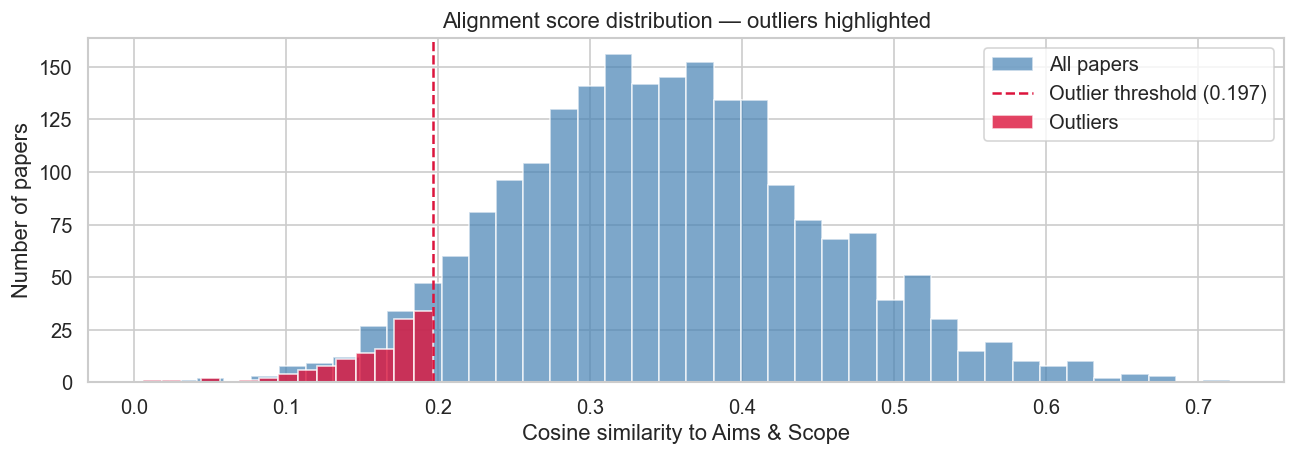

In [26]:
# Visualise outliers on the score distribution
fig, ax = plt.subplots(figsize=(11, 4))

ax.hist(df["alignment_score"], bins=40,
        color="steelblue", edgecolor="white", alpha=0.7, label="All papers")
ax.axvline(threshold, color="crimson", linestyle="--", linewidth=1.5,
           label=f"Outlier threshold ({threshold:.3f})")
ax.hist(outliers["alignment_score"], bins=15,
        color="crimson", edgecolor="white", alpha=0.8, label="Outliers")

ax.set_title("Alignment score distribution — outliers highlighted")
ax.set_xlabel("Cosine similarity to Aims & Scope")
ax.set_ylabel("Number of papers")
ax.legend()
plt.tight_layout()
plt.savefig("../data/fig_outliers.png", dpi=150)
plt.show()

In [27]:
# Categorise outliers into meaningful groups
def categorise_outlier(title: str, abstract: str) -> str:
    title    = title.lower()
    abstract = abstract.lower()
    text     = title + " " + abstract
    
    if any(w in text for w in ["corrigendum", "erratum", "correction to"]):
        return "Editorial correction"
    elif any(w in text for w in ["fertilizer", "crop", "farming", "farmer", "agricultural training", "soil"]):
        return "Pure agronomy"
    elif any(w in text for w in ["covid", "particulate matter", "mortality", "epidemi", "hospital"]):
        return "Public health / epidemiology"
    elif any(w in text for w in ["mafia", "crime", "criminal", "fraud"]):
        return "Criminology"
    elif any(w in text for w in ["gdp growth", "exponential growth", "business cycle", "macroeconomic"]):
        return "Pure macroeconomics"
    elif any(w in text for w in ["aircraft", "aviation", "airline"]):
        return "Transport engineering"
    else:
        return "Other / peripheral"

outliers["category"] = outliers.apply(
    lambda row: categorise_outlier(row["title"], row["abstract"]), axis=1
)

# Summary table
category_counts = outliers["category"].value_counts().reset_index()
category_counts.columns = ["category", "count"]
category_counts["mean_score"] = category_counts["category"].apply(
    lambda c: outliers[outliers["category"] == c]["alignment_score"].mean().round(4)
)
print(category_counts.to_string(index=False))

                    category  count  mean_score
          Other / peripheral     92      0.1597
               Pure agronomy     14      0.1557
        Editorial correction     10      0.1499
Public health / epidemiology      6      0.1682
                 Criminology      4      0.1458
       Transport engineering      2      0.1430
         Pure macroeconomics      2      0.1744


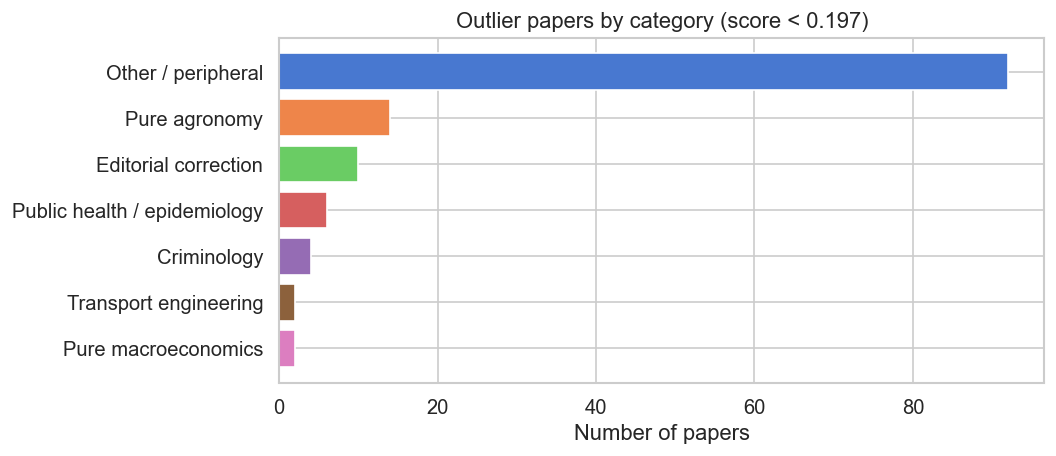

In [28]:
fig, ax = plt.subplots(figsize=(9, 4))
colors = sns.color_palette("muted", len(category_counts))
ax.barh(category_counts["category"], category_counts["count"],
        color=colors, edgecolor="white")
ax.set_title("Outlier papers by category (score < 0.197)")
ax.set_xlabel("Number of papers")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("../data/fig_outlier_categories.png", dpi=150)
plt.show()

---
## 7. Topic Modelling with BERTopic

BERTopic identifies latent themes across the corpus by clustering documents in embedding space and extracting representative keywords for each cluster using a class-based TF-IDF procedure (Grootendorst, 2022).

This allows us to:
1. See what themes the journal actually publishes
2. Cross-tabulate topics with alignment scores (which themes score highest/lowest?)
3. Track which topics grew or shrank over time

In [31]:
from bertopic import BERTopic
from sklearn.cluster import MiniBatchKMeans
from sklearn.decomposition import IncrementalPCA
from umap import UMAP
from hdbscan import HDBSCAN

print("Fitting BERTopic model (lightweight config)...")

umap_model  = UMAP(n_components=5, n_neighbors=15,
                   min_dist=0.0, metric="cosine", random_state=42)
hdbscan_model = HDBSCAN(min_cluster_size=10, metric="euclidean",
                         cluster_selection_method="eom", prediction_data=True)

topic_model = BERTopic(
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    language="english",
    calculate_probabilities=False,   # saves a lot of memory
    verbose=True,
    nr_topics="auto",
)

topics, _ = topic_model.fit_transform(abstracts, abstract_vecs)

df["topic"] = topics
print(f"\nNumber of topics found: {len(set(topics)) - 1}")
topic_model.get_topic_info().head(15)

2026-05-15 14:26:17,798 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm


Fitting BERTopic model (lightweight config)...


2026-05-15 14:26:21,918 - BERTopic - Dimensionality - Completed ✓
2026-05-15 14:26:21,919 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-05-15 14:26:21,947 - BERTopic - Cluster - Completed ✓
2026-05-15 14:26:21,947 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-05-15 14:26:22,076 - BERTopic - Representation - Completed ✓
2026-05-15 14:26:22,077 - BERTopic - Topic reduction - Reducing number of topics
2026-05-15 14:26:22,081 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-05-15 14:26:22,191 - BERTopic - Representation - Completed ✓
2026-05-15 14:26:22,192 - BERTopic - Topic reduction - Reduced number of topics from 43 to 17



Number of topics found: 16


,Topic,Count,Name,Representation,Representative_Docs
0,-1,766,-1_the_of_and_to,"[the, of, and, to, in, for, that, we, on, is]",[How can decentralized individual decisions inefficiently reduce the ability...
1,0,993,0_the_of_and_to,"[the, of, and, to, in, that, for, on, is, we]",[Lack of attention to social complexity has created a gap between current ec...
2,1,62,1_fishing_the_of_fisheries,"[fishing, the, of, fisheries, fishery, and, in, fish, to, fishers]","[Fishing connects people, aquatic systems, places, and fish consumer markets..."
3,2,37,2_environmental_the_of_regulation,"[environmental, the, of, regulation, and, firms, innovation, that, policy, to]",[Whether environmental regulation incentivizes green technology innovations ...
4,3,34,3_water_the_of_and,"[water, the, of, and, in, to, virtual, agricultural, that, by]","[Most of the water humanity currently consumes is invisible, it is embedded ..."
5,4,31,4_water_quality_the_to,"[water, quality, the, to, of, in, trading, and, we, nutrient]",[Agricultural nonpoint sources (NPS) figure prominently in the design of man...
6,5,28,5_financial_the_of_to,"[financial, the, of, to, green, firms, and, portfolio, risks, climate]",[Existing approaches to assess the economic impact of climate policies tend ...
7,6,25,6_circular_economy_the_and,"[circular, economy, the, and, of, to, is, in, business, circularity]",[The dominant conception of the circular economy presents it as a politicall...
8,7,24,7_wellbeing_subjective_satisfaction_life,"[wellbeing, subjective, satisfaction, life, the, of, in, we, nuclear, and]","[Rapid environmental degradation is a well-publicized issue, particularly in..."
9,8,22,8_air_pollution_the_of,"[air, pollution, the, of, in, environmental, and, to, that, we]",[This paper provides an empirical analysis on the relationship between incom...


In [32]:
from sklearn.feature_extraction.text import CountVectorizer

# Refit with stopwords removed for better topic labels
vectorizer = CountVectorizer(stop_words="english", ngram_range=(1, 2))

topic_model.update_topics(abstracts, vectorizer_model=vectorizer)

# Print meaningful topic keywords
print("Topics with meaningful keywords:\n")
topic_info = topic_model.get_topic_info()
for _, row in topic_info[topic_info["Topic"] != -1].iterrows():
    tid   = row["Topic"]
    count = row["Count"]
    words = [w for w, _ in topic_model.get_topic(tid)[:6]]
    print(f"Topic {tid}  ({count} papers)  →  {', '.join(words)}")

Topics with meaningful keywords:

Topic 0  (993 papers)  →  environmental, economic, results, social, paper, carbon
Topic 1  (62 papers)  →  fishing, fisheries, fishery, fish, fishers, economic
Topic 2  (37 papers)  →  environmental, regulation, firms, innovation, environmental regulation, policy
Topic 3  (34 papers)  →  water, virtual, virtual water, agricultural, water resources, economic
Topic 4  (31 papers)  →  water, water quality, quality, trading, nutrient, quality trading
Topic 5  (28 papers)  →  financial, green, firms, portfolio, risks, climate
Topic 6  (25 papers)  →  circular, circular economy, economy, business, circularity, ce
Topic 7  (24 papers)  →  wellbeing, subjective, subjective wellbeing, life satisfaction, satisfaction, life
Topic 8  (22 papers)  →  air, pollution, air pollution, environmental, noise, spatial
Topic 9  (19 papers)  →  insurance, flood, risk, climate, events, hazards
Topic 10  (16 papers)  →  resource, resources, resource users, scarcity, groups, th

In [33]:
# assign proper labels and get alignment scores per topic
topic_labels = {
    0:  "General ecological economics",
    1:  "Fisheries management",
    2:  "Environmental regulation & innovation",
    3:  "Virtual water & agriculture",
    4:  "Water quality trading",
    5:  "Green finance & climate risk",
    6:  "Circular economy",
    7:  "Subjective wellbeing",
    8:  "Air pollution & spatial analysis",
    9:  "Flood insurance & climate hazards",
    10: "Common-pool resources",
    11: "Urban green infrastructure",
    12: "Transport & mobility",
    13: "Energy rebound effects",
    14: "Waste & recycling",
    15: "Economic growth & decoupling",
}

df["topic_label"] = df["topic"].map(topic_labels).fillna("Uncategorised")

topic_scores = (
    df[df["topic"] != -1]
    .groupby("topic_label")["alignment_score"]
    .agg(mean="mean", std="std", count="count")
    .sort_values("mean", ascending=False)
    .round(4)
)
print(topic_scores)

                                         mean     std  count
topic_label                                                 
General ecological economics           0.3650  0.1055    993
Circular economy                       0.3594  0.0795     25
Economic growth & decoupling           0.3424  0.0608     11
Fisheries management                   0.3382  0.0729     62
Virtual water & agriculture            0.3040  0.0741     34
Energy rebound effects                 0.3039  0.0857     12
Common-pool resources                  0.2978  0.0794     16
Green finance & climate risk           0.2974  0.0839     28
Water quality trading                  0.2941  0.0781     31
Urban green infrastructure             0.2885  0.0756     16
Waste & recycling                      0.2803  0.0811     12
Flood insurance & climate hazards      0.2744  0.0777     19
Environmental regulation & innovation  0.2535  0.0622     37
Air pollution & spatial analysis       0.2419  0.0834     22
Transport & mobility    

### 7.1 Topic keywords

In [34]:
# Print top keywords for each topic
topic_info = topic_model.get_topic_info()
for _, row in topic_info[topic_info["Topic"] != -1].head(15).iterrows():
    tid = row["Topic"]
    words = [w for w, _ in topic_model.get_topic(tid)[:8]]
    print(f"Topic {tid:3d}  ({row['Count']:4d} papers)  →  {', '.join(words)}")

Topic   0  ( 993 papers)  →  environmental, economic, results, social, paper, carbon, ecosystem, climate
Topic   1  (  62 papers)  →  fishing, fisheries, fishery, fish, fishers, economic, model, bioeconomic
Topic   2  (  37 papers)  →  environmental, regulation, firms, innovation, environmental regulation, policy, effect, green
Topic   3  (  34 papers)  →  water, virtual, virtual water, agricultural, water resources, economic, production, trade
Topic   4  (  31 papers)  →  water, water quality, quality, trading, nutrient, quality trading, lake, costs
Topic   5  (  28 papers)  →  financial, green, firms, portfolio, risks, climate, funds, banks
Topic   6  (  25 papers)  →  circular, circular economy, economy, business, circularity, ce, companies, use
Topic   7  (  24 papers)  →  wellbeing, subjective, subjective wellbeing, life satisfaction, satisfaction, life, nuclear, individuals
Topic   8  (  22 papers)  →  air, pollution, air pollution, environmental, noise, spatial, exposure, areas


### 7.2 Mean alignment score per topic

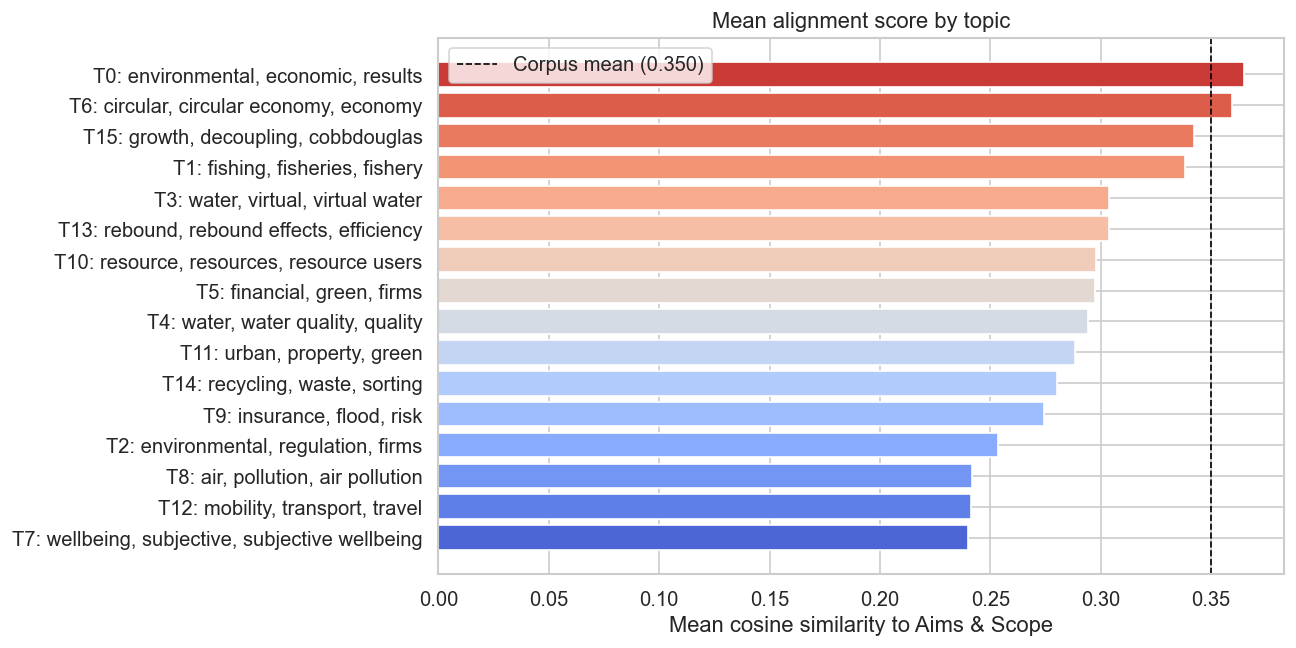

In [35]:
topic_scores = (
    df[df["topic"] != -1]
    .groupby("topic")["alignment_score"]
    .agg(mean="mean", count="count")
    .sort_values("mean", ascending=False)
    .reset_index()
)

# Add keyword label
def topic_label(tid):
    words = [w for w, _ in topic_model.get_topic(tid)[:3]]
    return f"T{tid}: {', '.join(words)}"

topic_scores["label"] = topic_scores["topic"].apply(topic_label)

fig, ax = plt.subplots(figsize=(11, max(5, len(topic_scores) * 0.35)))
bars = ax.barh(
    topic_scores["label"],
    topic_scores["mean"],
    color=sns.color_palette("coolwarm_r", len(topic_scores)),
    edgecolor="white",
)
ax.axvline(mean_score, color="black", linestyle="--",
           linewidth=1, label=f"Corpus mean ({mean_score:.3f})")
ax.set_title("Mean alignment score by topic")
ax.set_xlabel("Mean cosine similarity to Aims & Scope")
ax.legend()
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("../data/fig_topics_alignment.png", dpi=150)
plt.show()

### 7.3 Topic evolution over time

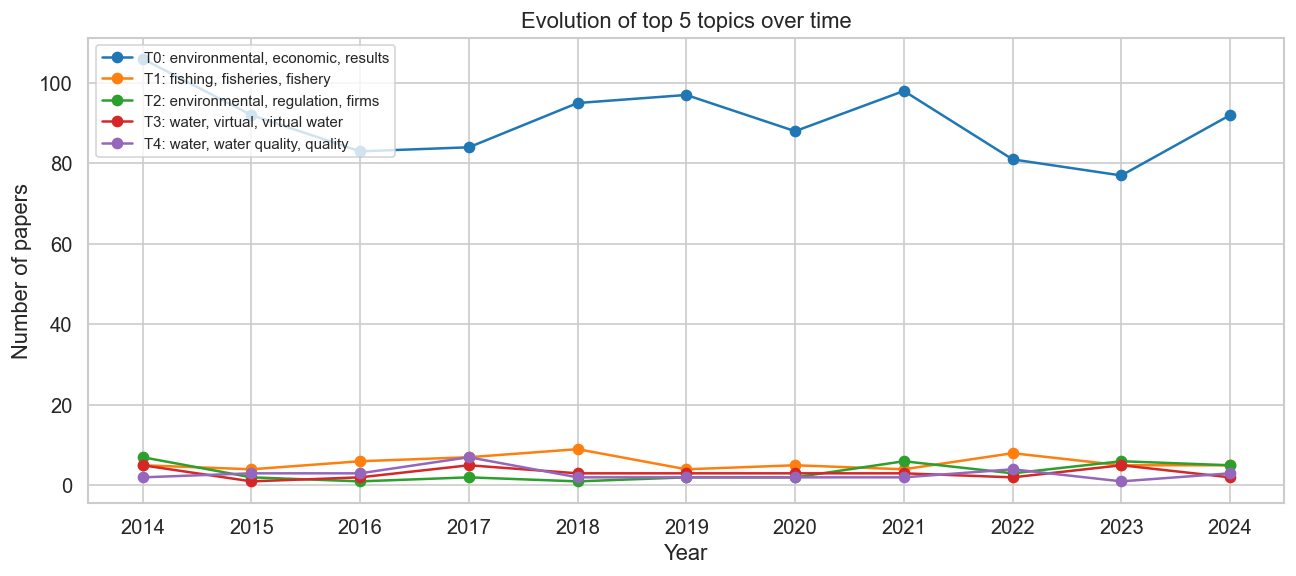

In [36]:
# Pick the 5 largest topics and track their share per year
top5_topics = (
    topic_scores[topic_scores["topic"] != -1]
    .nlargest(5, "count")["topic"]
    .tolist()
)

topic_year = (
    df[df["topic"].isin(top5_topics)]
    .groupby(["year", "topic"])
    .size()
    .reset_index(name="count")
)

fig, ax = plt.subplots(figsize=(11, 5))
palette = sns.color_palette("tab10", len(top5_topics))

for i, tid in enumerate(top5_topics):
    subset = topic_year[topic_year["topic"] == tid]
    label  = topic_label(tid)
    ax.plot(subset["year"], subset["count"],
            marker="o", label=label, color=palette[i])

ax.set_title("Evolution of top 5 topics over time")
ax.set_xlabel("Year")
ax.set_ylabel("Number of papers")
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
ax.legend(fontsize=9, loc="upper left")
plt.tight_layout()
plt.savefig("../data/fig_topic_evolution.png", dpi=150)
plt.show()

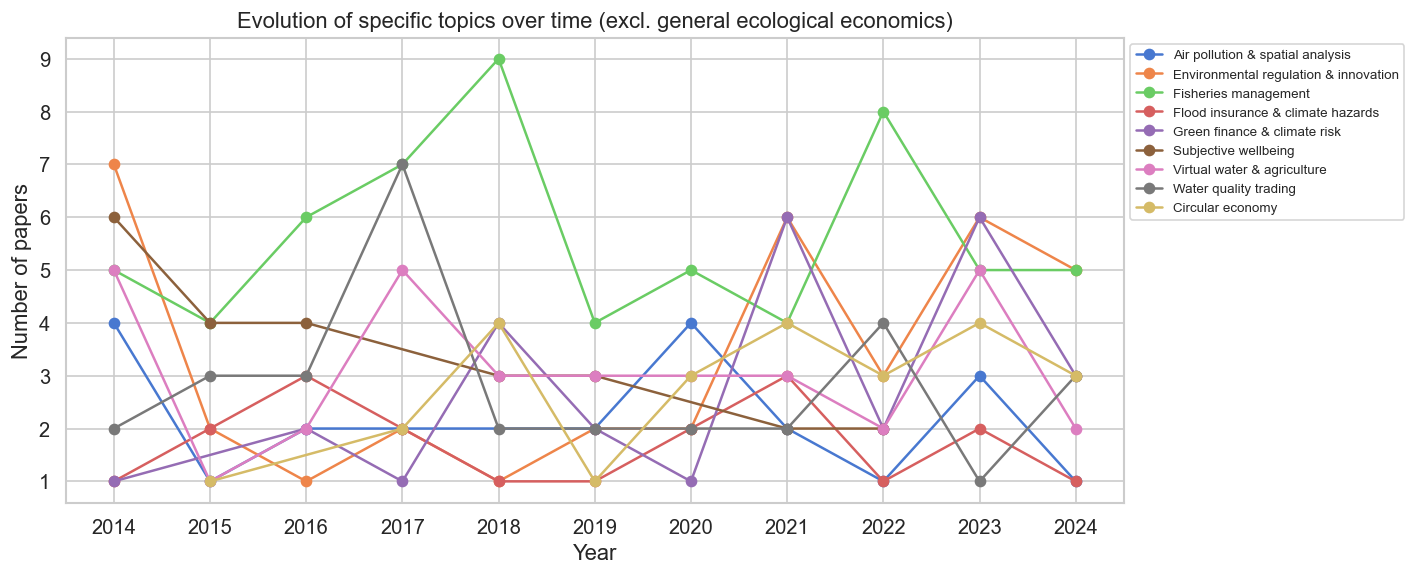

In [37]:
# Exclude topic 0 (too dominant) to see the smaller topics clearly
top_topics_small = [1, 2, 3, 4, 5, 6, 7, 8, 9]

topic_year = (
    df[df["topic"].isin(top_topics_small)]
    .groupby(["year", "topic_label"])
    .size()
    .reset_index(name="count")
)

fig, ax = plt.subplots(figsize=(12, 5))
palette = sns.color_palette("tab10", len(top_topics_small))

for i, label in enumerate(topic_year["topic_label"].unique()):
    subset = topic_year[topic_year["topic_label"] == label]
    ax.plot(subset["year"], subset["count"],
            marker="o", label=label, linewidth=1.5)

ax.set_title("Evolution of specific topics over time (excl. general ecological economics)")
ax.set_xlabel("Year")
ax.set_ylabel("Number of papers")
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
ax.legend(fontsize=8, loc="upper left", bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.savefig("../data/fig_topic_evolution.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 8. Qualitative Validation

Quantitative scores need to be grounded in reading actual papers. Here we inspect the highest and lowest scoring papers and reflect on whether the metric captures something meaningful.

In [38]:
print("=" * 65)
print("TOP 3 MOST ALIGNED PAPERS")
print("=" * 65)
for _, row in df.nlargest(3, "alignment_score").iterrows():
    print(f"\nScore : {row['alignment_score']:.4f}")
    print(f"Title : {row['title']}")
    print(f"Year  : {row['year']}")
    print(f"Abstract (first 300 chars):\n{row['abstract'][:300]}...")
    print("-" * 65)

TOP 3 MOST ALIGNED PAPERS

Score : 0.7213
Title : Why ecological economics needs to return to its roots: The biophysical foundation of socio-economic systems
Year  : 2020
Abstract (first 300 chars):
Ecological economics was formally established in 1989 with the ambitious vision of developing a new economic paradigm embedding the social and economic systems in the biophysical world. Ecological economics had its roots in the biophysical understanding of economics that pioneers of the field George...
-----------------------------------------------------------------

Score : 0.6842
Title : Between Ostrom and Nordhaus: The research landscape of sustainability economics
Year  : 2020
Abstract (first 300 chars):
We survey the emerging research area of sustainability economics through a quantitative full-text analysis of peer-reviewed journal publications from 1987 to 2013. To identify relevant contributions, we draw on existing definitions of sustainability economics for a keyword-based identi

In [39]:
print("=" * 65)
print("BOTTOM 3 LEAST ALIGNED PAPERS")
print("=" * 65)
for _, row in df.nsmallest(3, "alignment_score").iterrows():
    print(f"\nScore : {row['alignment_score']:.4f}")
    print(f"Title : {row['title']}")
    print(f"Year  : {row['year']}")
    print(f"Abstract (first 300 chars):\n{row['abstract'][:300]}...")
    print("-" * 65)

BOTTOM 3 LEAST ALIGNED PAPERS

Score : 0.0057
Title : Corrigendum to Moral Foundations and Voluntary Public Good Provision: The Case of Climate Change (Ecological Economics (2020) 175, (S0921800919315319), (10.1016/j.ecolecon.2020.106696))
Year  : 2020
Abstract (first 300 chars):
The authors regret two reporting errors (wrong signs) in Table A2. The correct coefficient of the regression of Care with respect to Left-Right Scale is −0.02: The correct coefficient of the regression of Fairness with respect to Left-Right Scale is −0.08. The authors would like to apologise for any...
-----------------------------------------------------------------

Score : 0.0288
Title : The Role of Agricultural Training on Fertilizer Use Knowledge: A Randomized Controlled Experiment
Year  : 2018
Abstract (first 300 chars):
Improving farmers’ knowledge of fertilizer use through agricultural training has been considered a prerequisite to scientific fertilizer management. However, empirical evidence of the ef

---
## 9. Summary of Findings

*(Fill this in after running all cells and seeing your results)*

| Finding | Value |
|---------|-------|
| Total papers analysed | *(fill in)* |
| Year range | 2014 – 2024 |
| Mean alignment score | *(fill in)* |
| Number of outliers | *(fill in)* |
| Drift detected? | *(yes/no — fill in)* |
| Number of topics found | *(fill in)* |
| Highest-scoring topic | *(fill in)* |
| Lowest-scoring topic | *(fill in)* |

### Interpretation

*Write 3–5 sentences here after you see the results. For example:*

- *Did the journal drift toward or away from its scope over time?*
- *What kinds of papers scored lowest — are they truly off-topic or does the metric have limitations?*
- *Which topics dominate the journal and do they match the Aims & Scope keywords?*

---
## 10. Export Results

In [40]:
# Save the full results table for the report
output_cols = ["year", "title", "doi", "date", "alignment_score", "topic"]
df[output_cols].to_csv("../data/results.csv", index=False)
print("Results saved to data/results.csv")

# Save yearly drift table
yearly.to_csv("../data/yearly_drift.csv", index=False)
print("Yearly drift saved to data/yearly_drift.csv")

print("\nAll done!")

Results saved to data/results.csv
Yearly drift saved to data/yearly_drift.csv

All done!


---
## References

- Grootendorst, M. (2022). BERTopic: Neural topic modeling with a class-based TF-IDF procedure. *arXiv preprint arXiv:2203.05794*.
- Reimers, N., & Gurevych, I. (2019). Sentence-BERT: Sentence Embeddings using Siamese BERT-Networks. *Proceedings of EMNLP-IJCNLP*, 3982–3992.
- Picascia, S., Montanelli, S., Salini, S., & Verzillo, S. (2025). The Atlas of Data Science Research. *IEEE Access*.
- Hassan-Montero, Y. et al. (2014). Graphical interface of the Scimago Journal and Country Rank. *El profesional de la información*, 23(3).